#WineQT DAta Analysis

#Importing required python libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns

#Importing the dataset for analysis

In [ ]:
df=pd.read_csv("/content/WineQT.csv")

In [ ]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


#Droping the unnecessary feature

In [ ]:
df.drop('Id',axis=1,inplace=True)

In [ ]:
df.tail()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1142,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [ ]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 107.3 KB


In [ ]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


#Checking for the duplicates

In [ ]:
df.duplicated().sum()

np.int64(125)

#Removing the duplicates

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:

df.duplicated().sum()


np.int64(0)

## Duplicate Handling

The dataset contained 125 duplicate records. These duplicates were identified using the duplicated() function and removed using drop_duplicates(). Removing duplicate observations improves data quality and helps prevent bias during model training.

In [ ]:
df['quality'].value_counts()

,count
quality,
5,433
6,409
7,122
4,33
8,15
3,6


#Spliting dataset into X and Y

In [ ]:
X=df.drop('quality' , axis=1)

In [ ]:
Y=df['quality']

#Standardize the input data

In [ ]:

from sklearn.preprocessing import StandardScaler
Scalar=StandardScaler()
X_scaled=Scalar.fit_transform(X)

# Splitting the Dataset

To evaluate the machine learning model effectively, the dataset is divided into training and testing sets.

- Training Set (80%): Used to train the model.
- Testing Set (20%): Used to evaluate model performance on unseen data.


In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test= train_test_split(X_scaled,Y,test_size=0.2,random_state=42)

#Building the model

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, Y_train)



RandomForestClassifier(random_state=42)

In [ ]:
rf_pred = rf.predict(X_test)

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(
    random_state=42
)

sgd.fit(X_train, Y_train)

SGDClassifier(random_state=42)

In [ ]:
sgd_pred = sgd.predict(X_test)

print(sgd_pred)

[5 6 7 5 5 7 7 5 6 7 5 6 5 6 6 7 7 6 5 5 5 6 6 6 6 5 6 6 6 6 5 6 6 5 6 5 6
 5 6 5 6 5 5 6 6 5 5 6 6 6 6 6 7 5 6 5 6 7 5 6 5 6 6 7 6 5 5 5 5 5 6 6 6 6
 6 6 6 5 6 5 6 6 5 6 6 5 6 5 6 6 6 5 6 6 5 6 5 6 6 5 5 6 6 6 5 7 6 6 5 6 6
 5 7 5 5 6 5 6 5 6 6 6 5 6 7 6 5 5 6 5 5 5 6 6 5 6 6 7 6 6 7 5 5 6 5 5 5 7
 6 5 6 5 5 6 5 5 5 7 5 5 6 6 5 5 5 6 6 6 6 7 6 6 6 6 5 5 5 6 5 6 7 5 5 7 6
 5 6 6 6 6 6 6 6 6 6 7 5 5 6 5 7 6 6 6]


In [ ]:
from sklearn.svm import SVC

svc = SVC(
    kernel='rbf'
)

svc.fit(X_train, Y_train)

SVC()

In [ ]:
svc_pred = svc.predict(X_test)
print(svc_pred)

[5 6 7 6 5 6 7 6 6 6 5 5 5 6 6 6 7 6 5 5 5 6 5 5 6 5 5 6 6 5 6 5 5 5 6 5 5
 5 6 5 7 5 5 7 6 5 5 7 7 6 6 6 6 5 5 6 6 6 5 6 5 6 6 6 6 5 5 5 5 5 5 5 5 6
 6 6 5 6 6 5 7 6 5 6 6 5 6 6 6 5 6 5 5 6 5 6 5 6 6 5 5 6 6 6 5 7 6 6 5 6 5
 5 7 5 5 6 5 5 6 6 6 6 5 6 6 6 5 5 6 5 5 5 5 6 5 6 6 6 6 6 6 5 5 5 5 5 5 7
 6 6 6 5 5 6 5 6 5 6 5 5 5 6 6 5 5 6 6 7 5 6 6 6 6 6 5 5 5 6 6 6 7 5 6 7 5
 5 6 6 6 6 5 6 6 6 5 7 5 5 5 5 7 5 7 6]


#Checking accuracy of all the models

In [ ]:
from sklearn.metrics import accuracy_score

rf_acc = accuracy_score(Y_test, rf_pred)

sgd_acc = accuracy_score(Y_test, sgd_pred)

svc_acc = accuracy_score(Y_test, svc_pred)



In [ ]:
print("Random Forest Accuracy :", rf_acc)

Random Forest Accuracy : 0.5441176470588235


In [ ]:
print("SGD Accuracy :", sgd_acc)

SGD Accuracy : 0.5490196078431373


In [ ]:
print("SVC Accuracy:",sgd_acc)

SVC Accuracy: 0.5490196078431373


#Comparing accuracy of all the models

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Model': ['Random Forest', 'SGD', 'SVC'],
    'Accuracy': [rf_acc, sgd_acc, svc_acc]
})

results.sort_values(
    by='Accuracy',
    ascending=False
)

,Model,Accuracy
2,SVC,0.553922
1,SGD,0.549020
0,Random Forest,0.544118


In [ ]:
corr = df.corr(numeric_only=True)

print(corr['quality'].sort_values(ascending=False))

quality                 1.000000
alcohol                 0.485953
sulphates               0.257519
citric acid             0.241565
fixed acidity           0.115826
residual sugar          0.022718
pH                     -0.057592
free sulfur dioxide    -0.071083
chlorides              -0.122214
total sulfur dioxide   -0.182214
density                -0.185187
volatile acidity       -0.409340
Name: quality, dtype: float64


#Visualization

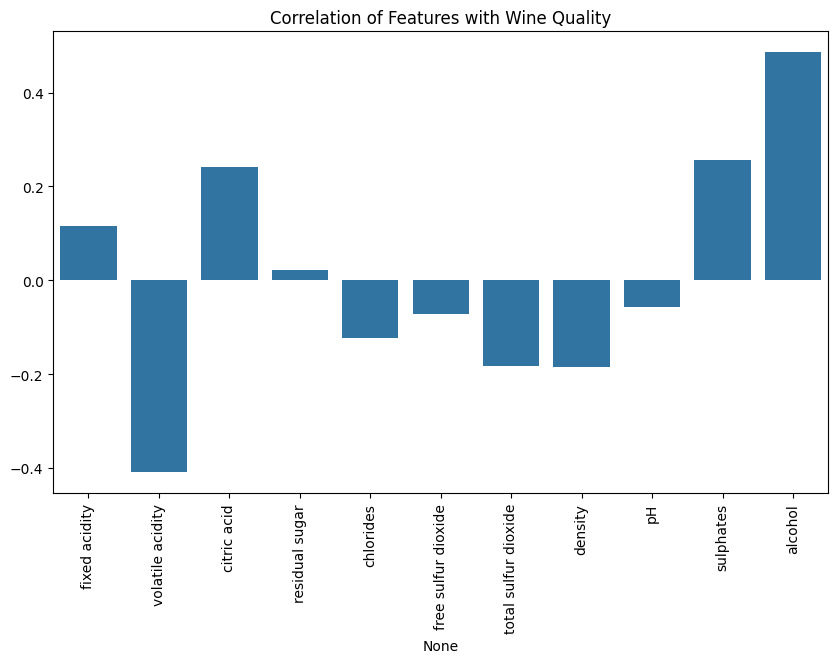

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.barplot(
    x=corr['quality'].drop('quality').index,
    y=corr['quality'].drop('quality').values
)

plt.xticks(rotation=90)
plt.title('Correlation of Features with Wine Quality')
plt.show()

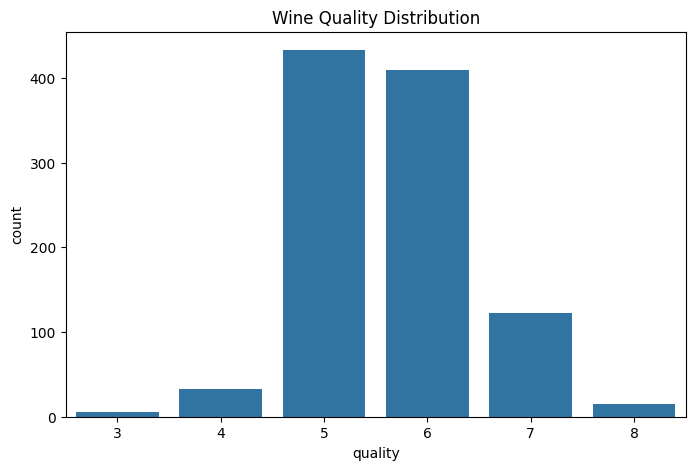

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='quality',
    data=df
)

plt.title('Wine Quality Distribution')
plt.show()

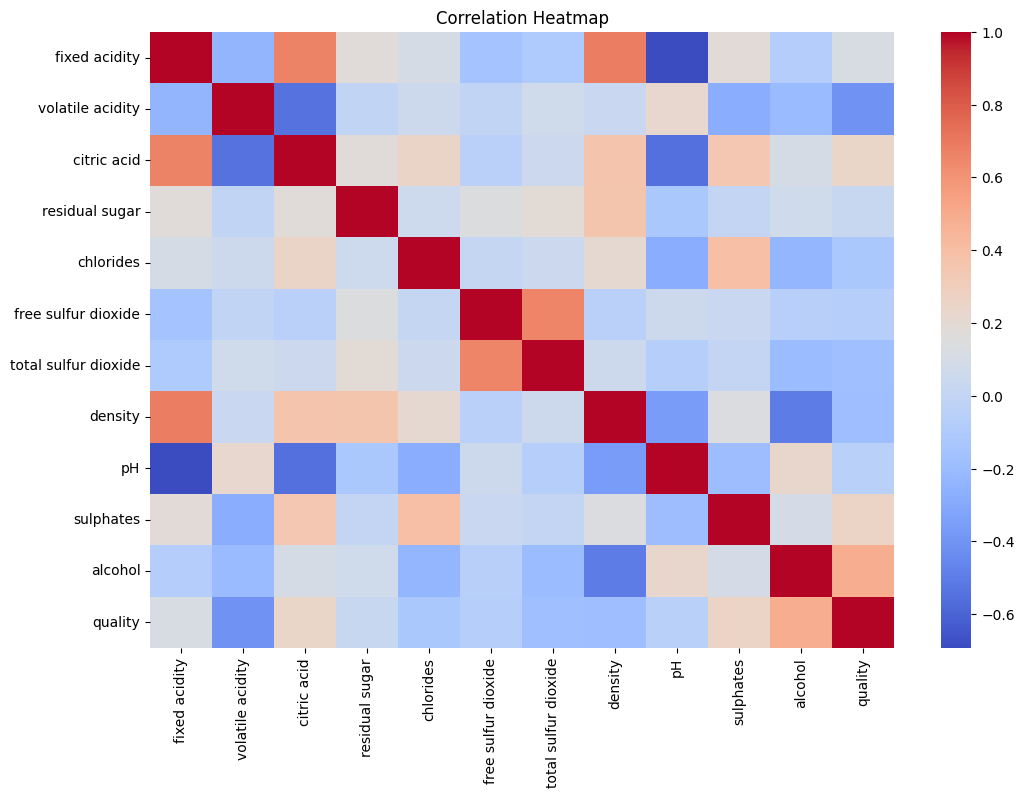

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

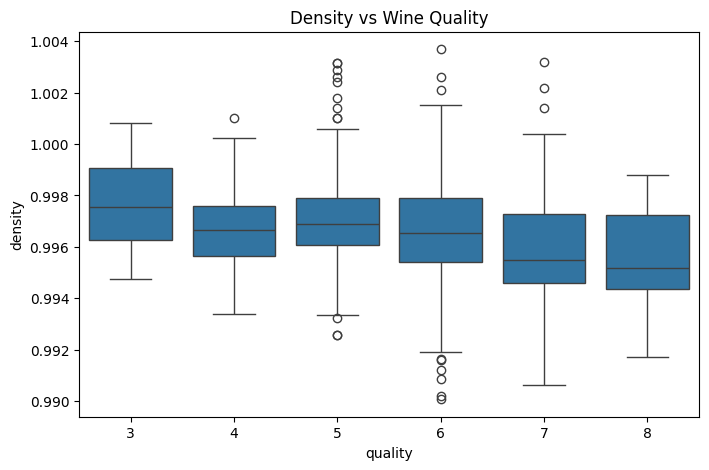

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='quality',
    y='density',
    data=df
)

plt.title('Density vs Wine Quality')
plt.show()

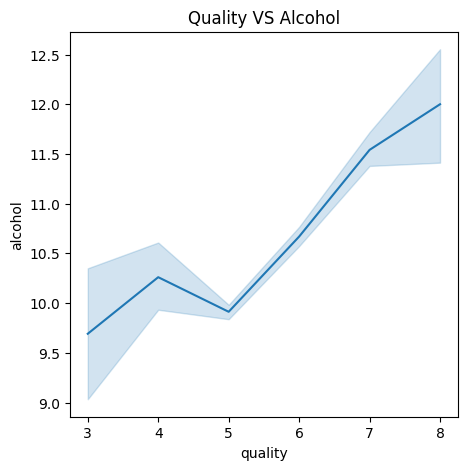

In [ ]:
plt.figure(figsize=(5,5))
sns.lineplot(
    x='quality',
    y='alcohol',
    data=df

)

plt.title( 'Quality VS Alcohol')
plt.show()